# **UCI HAR - CBAM**
- CBAM(Channel and Spatial Attention Module)은 CNN에서 성능을 향상시키기 위해 제안된 어텐션 모듈이다.
- 입력 피처 맵에서 중요한 정보를 강조하고 덜 중요한 정보를 억제함으로써, 모델이 더 중요한 특성에 집중할 수 있도록 도움을 준다.
- Channel Attention과 Spatial Attention의 두 가지 어텐션 메커니즘을 결합한 구조

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input, Model, backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, GlobalAveragePooling1D, GlobalMaxPooling1D, Dense, Reshape, Multiply, Concatenate, MaxPooling1D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [5]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/drive/MyDrive/AI_Study/UCI_HAR_Dataset/"

In [6]:
# Load "X"
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []                                        # 한 센서축 데이터 전체 저장

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')              # 공백 2개를 1개로
                row_clean = row_clean.strip()                   # 양쪽 공백 제거
                serie = row_clean.split(' ')                    # 공백 기준 split
                serie_array = np.array(serie, dtype=np.float32) # float32 numpy 배열로 변환
                series_list.append(serie_array)                 # 시퀀스 추가

        # 하나의 센서축 데이터 추가 (feature)
        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)
    # shape 변환 → (샘플 수, 타임스텝 수, 특성 수)
    return np.transpose(X_signals, (1, 2, 0))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("첫 번째 샘플 데이터:\n", X_train[0])

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
첫 번째 샘플 데이터:
 [[ 1.808515e-04  1.076681e-02  5.556068e-02 ...  1.012817e+00
  -1.232167e-01  1.029341e-01]
 [ 1.013856e-02  6.579480e-03  5.512483e-02 ...  1.022833e+00
  -1.268756e-01  1.056872e-01]
 [ 9.275574e-03  8.928878e-03  4.840473e-02 ...  1.022028e+00
  -1.240037e-01  1.021025e-01]
 ...
 [-1.147484e-03  1.714439e-04  2.647864e-03 ...  1.018445e+00
  -1.240696e-01  1.003852e-01]
 [-2.222655e-04  1.574181e-03  2.381057e-03 ...  1.019372e+00
  -1.227451e-01  9.987355e-02]
 [ 1.575500e-03  3.070189e-03 -2.269757e-03 ...  1.021171e+00
  -1.213260e-01  9.498741e-02]]


In [7]:
# Load "y"

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 라벨을 0부터 시작하도록 -1 (원래 라벨이 1부터 시작)
    return np.array(labels, dtype=np.int32) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

# 정답 레이블을 원-핫 인코딩으로 변환 (클래스 개수 = 6)
y_train_onehot = to_categorical(y_train, num_classes=6)
y_test_onehot = to_categorical(y_test, num_classes=6)

print("원본 정답 쉐입:", y_train.shape)              # (7352,)
print("원-핫 인코딩 후 쉐입:", y_train_onehot.shape) # 변환 후: (7352, 6)

print(y_train_onehot[:5])

원본 정답 쉐입: (7352,)
원-핫 인코딩 후 쉐입: (7352, 6)
[[0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]]


# Model Building
- CBAM (Convolutional Block Attention Module) 구조를 1D CNN에 맞춰 적용
  - Channel Attention Module : 먼저 입력 피처 맵에 대해 채널별로 중요한 정보를 학습하고, 채널별로 가중치를 적용
  - Spatial Attention Module : 채널 어텐션이 적용된 피처 맵에 대해 공간적으로 중요한 영역을 학습하여 위치별로 다른 가중치를 적용
  - Global Average Pooling(정보를 압축) + Global Max Pooling(가장 의미 있는 정보 추출)

In [9]:
from tensorflow.keras import ops  # Keras 3 연산 모듈 임포트

input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = 6

K.clear_session()

# --- CBAM (Channel & Spatial Attention) 블록 정의 ---
def cbam_block(input_tensor, reduction_ratio=16):
    channels = input_tensor.shape[-1]

    # ==========================================
    # 1. Channel Attention Module (채널 어텐션)
    # ==========================================
    shared_dense_1 = Dense(channels // reduction_ratio, activation='relu')
    shared_dense_2 = Dense(channels)

    # AvgPool 경로
    avg_pool = GlobalAveragePooling1D()(input_tensor)
    avg_out = shared_dense_1(avg_pool)
    avg_out = shared_dense_2(avg_out)

    # MaxPool 경로
    max_pool = GlobalMaxPooling1D()(input_tensor)
    max_out = shared_dense_1(max_pool)
    max_out = shared_dense_2(max_out)

    # 두 결과를 더한 뒤 Sigmoid로 가중치 계산
    channel_attention = tf.keras.layers.Add()([avg_out, max_out])
    channel_attention = tf.keras.layers.Activation('sigmoid')(channel_attention)

    # 차원 확장 후 적용
    channel_attention = Reshape((1, channels))(channel_attention)
    scale_channel = Multiply()([input_tensor, channel_attention])

    # ==========================================
    # 2. Spatial Attention Module (공간/시간 어텐션)
    # ==========================================
    spatial_avg = ops.mean(scale_channel, axis=-1, keepdims=True)
    spatial_max = ops.max(scale_channel, axis=-1, keepdims=True)

    # 두 피처맵을 채널 방향으로 결합
    spatial_concat = Concatenate(axis=-1)([spatial_avg, spatial_max])

    # 1D Convolution을 통과시켜 공간적 특징 추출
    spatial_attention = Conv1D(filters=1, kernel_size=7, padding='same', activation='sigmoid')(spatial_concat)

    # 최종 공간 어텐션 가중치 적용
    scale_spatial = Multiply()([scale_channel, spatial_attention])

    return scale_spatial

# --- 전체 모델 빌딩 ---
inputs = Input(shape=input_shape)

# 첫 번째 특징 추출
x = Conv1D(128, 7, padding='same')(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)
x = cbam_block(x, reduction_ratio=16) # ★ CBAM 블록 적용

# 두 번째 특징 추출 (+ MaxPooling으로 압축)
x = Conv1D(256, 5, padding='same')(x)
x = BatchNormalization()(x)
x = ReLU()(x)
x = cbam_block(x, reduction_ratio=16) # ★ CBAM 블록 적용
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)

# 세 번째 특징 추출
x = Conv1D(256, 5, padding='same')(x)
x = BatchNormalization()(x)
x = ReLU()(x)
x = cbam_block(x, reduction_ratio=16) # ★ CBAM 블록 적용

# 네 번째 특징 추출 (+ MaxPooling으로 압축)
x = Conv1D(256, 3, padding='same')(x)
x = BatchNormalization()(x)
x = ReLU()(x)
x = cbam_block(x, reduction_ratio=16) # ★ CBAM 블록 적용
x = MaxPooling1D(2)(x)

# 차원 축소 및 데이터 요약
x = GlobalAveragePooling1D()(x)

# 은닉층 (Dense)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# 최종 출력층
outputs = Dense(num_classes, activation='softmax')(x)

# 모델 생성
model = Model(inputs=inputs, outputs=outputs)

# 컴파일 설정
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 128)  │      8,192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ re_lu[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │      1,032 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      1,152 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 128)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128, 128)  │          0 │ re_lu[0][0],      │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Mean)         │ (None, 128, 1)    │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max (Max)           │ (None, 128, 1)    │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 2)    │          0 │ mean[0][0],       │
│ (Concatenate)       │                   │            │ max[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 1)    │         15 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 128, 128)  │          0 │ multiply[0][0],   │
│ (Multiply)          │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 256)  │    164,096 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256)  │      1,024 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 796,666 (3.04 MB)

 Trainable params: 794,362 (3.03 MB)

 Non-trainable params: 2,304 (9.00 KB)

None


In [10]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [11]:
callbacks = [
            ModelCheckpoint(
                "UCI_HAR_CBAM_best.keras",
                save_best_only=True,
                monitor="val_categorical_accuracy",
                mode='max',
                verbose=1
            ),
            EarlyStopping(
                monitor="val_categorical_accuracy",
                patience=25,
                verbose=1,
                mode='max',
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.2,
                patience=8,
                min_lr=0.00001,
                verbose=1
            )
        ]

In [12]:
history = model.fit(
            X_train, y_train_onehot,
            epochs=100,
            batch_size=16,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )

Epoch 1/100
368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8294 - loss: 0.5010

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_categorical_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to UCI_HAR_CBAM_best.keras
368/368 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.8847 - loss: 0.3284 - val_accuracy: 0.7417 - val_loss: 0.6548 - learning_rate: 0.0010
Epoch 2/100


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_categorical_accuracy` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)


365/368 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9251 - loss: 0.2059
Epoch 2: finished saving model to UCI_HAR_CBAM_best.keras
368/368 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9325 - loss: 0.1897 - val_accuracy: 0.9273 - val_loss: 0.2386 - learning_rate: 0.0010
Epoch 3/100
362/368 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9351 - loss: 0.1760
Epoch 3: finished saving model to UCI_HAR_CBAM_best.keras
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9367 - loss: 0.1638 - val_accuracy: 0.9191 - val_loss: 0.2237 - learning_rate: 0.0010
Epoch 4/100
361/368 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9441 - loss: 0.1374
Epoch 4: finished saving model to UCI_HAR_CBAM_best.keras
368/368 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9415 - loss: 0.1439 - val_accuracy: 0.9164 - val_loss: 0.2497 - learning_rate: 0.0010
Epoch 5/100
363/368 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9457 - loss: 0.1268
Epoch 5: finished saving model to UCI_HAR_CBAM_best.keras
368/368 

In [14]:
# best 기록 확인
model = tf.keras.models.load_model("UCI_HAR_CBAM_best.keras")

train_loss, train_acc = model.evaluate(X_train, y_train_onehot, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(X_test, y_test_onehot, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.02%
Training loss: 0.0502
Test accuracy: 95.39%
Test loss: 0.2310


In [17]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# 분류 리포트
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9476    0.9731       496
           1     0.9978    0.9469    0.9717       471
           2     0.8994    1.0000    0.9470       420
           3     0.9653    0.8493    0.9036       491
           4     0.9124    0.9793    0.9447       532
           5     0.9589    1.0000    0.9790       537

    accuracy                         0.9539      2947
   macro avg     0.9556    0.9539    0.9532      2947
weighted avg     0.9562    0.9539    0.9535      2947



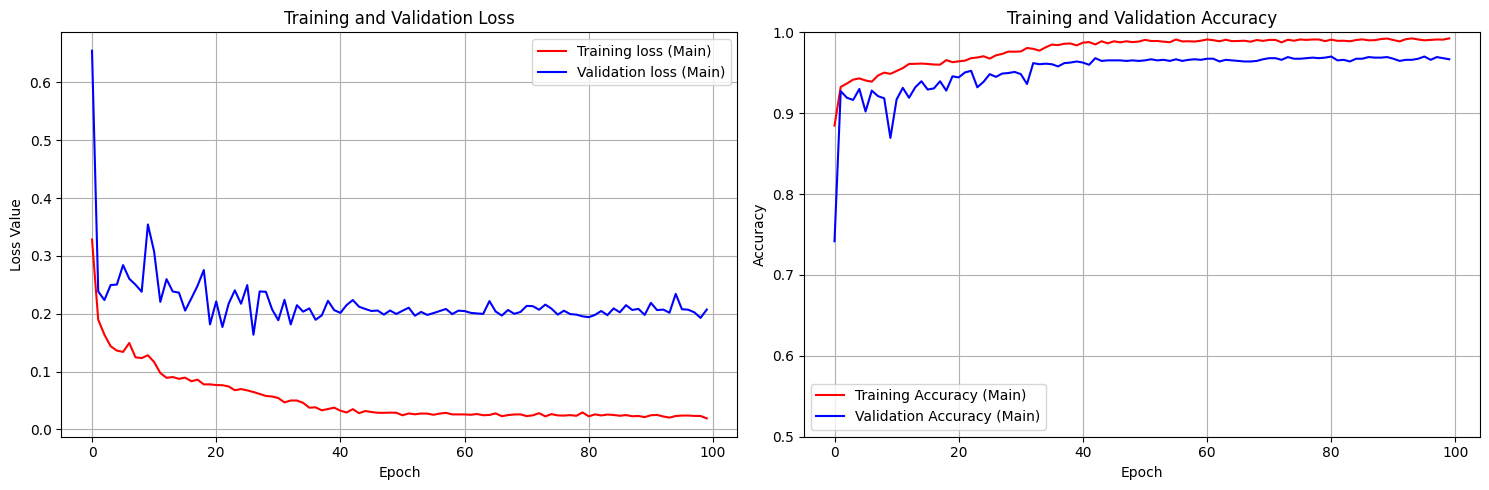

In [18]:
# loss / accuracy 그래프
train_loss = history.history['loss']
train_accuracy = history.history['accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss (Main)')
plt.plot(val_loss, 'b', label='Validation loss (Main)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.0])
plt.plot(train_accuracy, 'r', label='Training Accuracy (Main)')
plt.plot(val_accuracy, 'b', label='Validation Accuracy (Main)')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

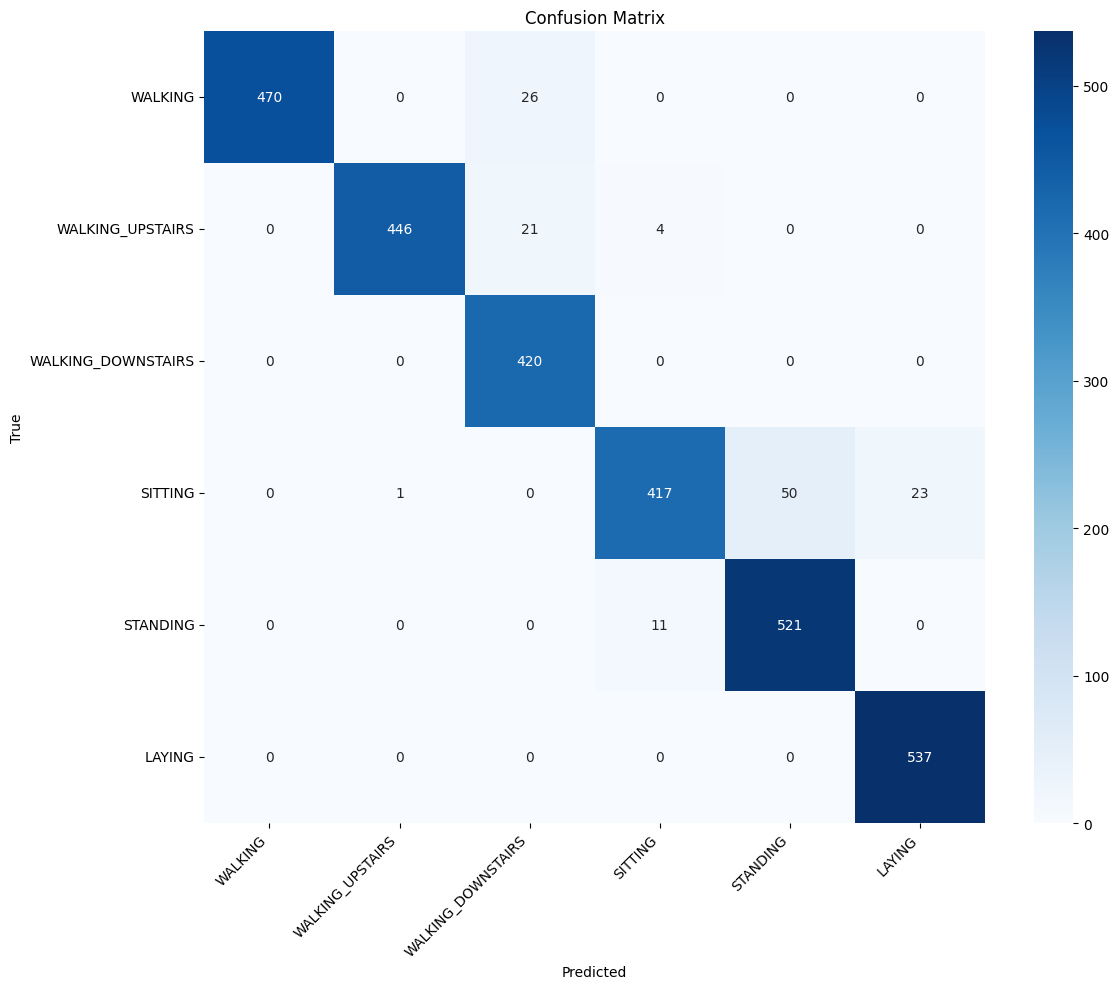

In [19]:
# 혼동행렬(히트맵)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()